### Importa os pacotes de sistema, análise, visualização, teste, ML e explainer

In [1]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install --upgrade numpy==1.24


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy
import shap

In [4]:
import os
## for data
import pandas as pd
import numpy as np
## for plotting
import matplotlib.pyplot as plt
import seaborn as sns
## for statistical tests
import scipy
import statsmodels.formula.api as smf
import statsmodels.api as sm
## for machine learning
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition
## for explainer
from lime import lime_tabular

In [5]:
#ESSE É O PARAMETRO QUE VAI INICIALIZAR AS SEMENTES DE MODELOS, SPLITTERS DE CONJUNTO DE TESTE/TREINAMENTO. 
#SERVE PRA TER UM MESMO RESULTADO AO VOCE USAR UM MESMO VALOR
roll_dice=0

### Ingere os dados baixados do git do Fake.BR Corpus

Notícias e target

In [6]:
lista_strings_fake = list()
lista_strings_true = list()

path_fake_news = "Fake.br-Corpus-master/full_texts/fake/"
path_true_news = "Fake.br-Corpus-master/full_texts/true/"

lista_arquivos_fake = os.listdir(path_fake_news)
lista_fake = [1] * len(lista_arquivos_fake)
lista_arquivos_true = os.listdir(path_true_news)
lista_true  = [0] * len(lista_arquivos_true)

for arquivo in lista_arquivos_fake:
    with open(path_fake_news+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_fake.append(lines)
for arquivo in lista_arquivos_true:
    with open(path_true_news+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_true.append(lines)
df_fake = pd.DataFrame([lista_strings_fake, lista_fake]).T
df_true = pd.DataFrame([lista_strings_true, lista_true]).T
df = pd.concat([df_fake, df_true])

Features

In [7]:
lista_strings_fake_meta_information = list()
lista_strings_true_meta_information = list()

path_fake_features = "Fake.br-Corpus-master/full_texts/fake-meta-information/"
path_true_features = "Fake.br-Corpus-master/full_texts/true-meta-information/"

lista_arquivos_fake_meta_information = os.listdir(path_fake_features)
lista_fake_meta_information = [1] * len(lista_arquivos_fake_meta_information)
lista_arquivos_true_meta_information = os.listdir(path_true_features)
lista_true_meta_information  = [0] * len(lista_arquivos_true_meta_information)

for arquivo in lista_arquivos_fake_meta_information:
    with open(path_fake_features+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_fake_meta_information.append(lines)
for arquivo in lista_arquivos_true_meta_information:
    with open(path_true_features+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_true_meta_information.append(lines)
    
df_fake_meta_information = pd.DataFrame([lista_strings_fake_meta_information, lista_fake_meta_information]).T
df_true_meta_information = pd.DataFrame([lista_strings_true_meta_information, lista_true_meta_information]).T
df_meta_information = pd.concat([df_fake_meta_information, df_true_meta_information])

Desempacota as features da lista em colunas diferentes do df de features

In [8]:
df_meta_information['author']=df_meta_information[0].apply(lambda i:i[0])
df_meta_information['link']=df_meta_information[0].apply(lambda i:i[1])
df_meta_information['category']=df_meta_information[0].apply(lambda i:i[2])
df_meta_information['date_of_publication']=df_meta_information[0].apply(lambda i:i[3])
df_meta_information['number_of_tokens']=df_meta_information[0].apply(lambda i:i[4])
df_meta_information['number_of_words_without_punctuation']=df_meta_information[0].apply(lambda i:i[5])
df_meta_information['number_of_types']=df_meta_information[0].apply(lambda i:i[6])
df_meta_information['number_of_links_inside_the_news']=df_meta_information[0].apply(lambda i:i[7])
df_meta_information['number_of_words_in_upper_case']=df_meta_information[0].apply(lambda i:i[8])
df_meta_information['number_of_verbs']=df_meta_information[0].apply(lambda i:i[9])
df_meta_information['number_of_subjuntive_and_imperative_verbs']=df_meta_information[0].apply(lambda i:i[10])
df_meta_information['number_of_nouns']=df_meta_information[0].apply(lambda i:i[11])
df_meta_information['number_of_adjectives']=df_meta_information[0].apply(lambda i:i[12])
df_meta_information['number_of_adverbs']=df_meta_information[0].apply(lambda i:i[13])
df_meta_information['number_of_modal_verbs']=df_meta_information[0].apply(lambda i:i[14])
df_meta_information['number_of_singular_first_and_second_personal_pronouns']=df_meta_information[0].apply(lambda i:i[15])
df_meta_information['number_of_plural_first_personal_pronouns']=df_meta_information[0].apply(lambda i:i[16])
df_meta_information['number_of_pronouns']=df_meta_information[0].apply(lambda i:i[17])
df_meta_information['pausality']=df_meta_information[0].apply(lambda i:i[18])
df_meta_information['number_of_characters']=df_meta_information[0].apply(lambda i:i[19])
df_meta_information['average_sentence_length']=df_meta_information[0].apply(lambda i:i[20])
df_meta_information['average_word_length']=df_meta_information[0].apply(lambda i:i[21])
df_meta_information['percentage_of_news_with_speeling_errors']=df_meta_information[0].apply(lambda i:i[22])
df_meta_information['emotiveness']=df_meta_information[0].apply(lambda i:i[23])
df_meta_information['diversity']=df_meta_information[0].apply(lambda i:i[24])

Trata tipologia dos dados

In [9]:
df_meta_information

,0,1,author,link,category,date_of_publication,number_of_tokens,number_of_words_without_punctuation,number_of_types,number_of_links_inside_the_news,...,number_of_singular_first_and_second_personal_pronouns,number_of_plural_first_personal_pronouns,number_of_pronouns,pausality,number_of_characters,average_sentence_length,average_word_length,percentage_of_news_with_speeling_errors,emotiveness,diversity
0,"[mrk\n, https://ceticismopolitico.com/2017/11/...",1,mrk\n,https://ceticismopolitico.com/2017/11/30/katia...,politica\n,2017-11-30\n,211\n,185\n,120\n,0\n,...,2\n,0\n,26\n,2.0\n,815\n,14.2308\n,4.40541\n,0.0\n,0.263158\n,0.648649
1,"[None\n, https://ceticismopolitico.com/2017/11...",1,None\n,https://ceticismopolitico.com/2017/11/24/dr-ra...,politica\n,2017-11-24\n,289\n,254\n,163\n,0\n,...,1\n,0\n,20\n,2.5\n,1205\n,18.1429\n,4.74409\n,0.00787402\n,0.241667\n,0.641732
2,"[None\n, https://afolhabrasil.com.br/politica/...",1,None\n,https://afolhabrasil.com.br/politica/reinaldo-...,politica\n,2017-05-23\n,304\n,275\n,170\n,0\n,...,0\n,0\n,18\n,1.8125\n,1344\n,17.1875\n,4.88727\n,0.00363636\n,0.12782\n,0.618182
3,"[None\n, https://www.diariodobrasil.org/relato...",1,None\n,https://www.diariodobrasil.org/relatorio-assus...,politica\n,24/07/2017\n,639\n,572\n,316\n,1\n,...,0\n,0\n,34\n,2.68\n,3122\n,22.88\n,5.45804\n,0.00174825\n,0.229008\n,0.552448
4,"[None\n, https://www.diariodobrasil.org/radial...",1,None\n,https://www.diariodobrasil.org/radialista-amer...,politica\n,25/07/2017\n,128\n,111\n,82\n,0\n,...,1\n,0\n,12\n,0.894737\n,515\n,5.84211\n,4.63964\n,0.0\n,0.269231\n,0.738739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,"[ Célia Froufe, correspondente, O Estado de S....",0,"Célia Froufe, correspondente, O Estado de S.P...","http://politica.estadao.com.br/noticias/geral,...",politica\n,22 de novembro de 2016 \n,637\n,567\n,291\n,0\n,...,0\n,0\n,27\n,3.5\n,2708\n,28.35\n,4.77601\n,0.00176367\n,0.141176\n,0.513228
3596,"[ Por G1, Brasília \n, https://g1.globo.com/po...",0,"Por G1, Brasília \n",https://g1.globo.com/politica/noticia/temer-di...,politica\n,09/02/2018 08h25 \n,1115\n,949\n,399\n,0\n,...,7\n,2\n,43\n,3.01818\n,4520\n,17.2545\n,4.76291\n,0.00210748\n,0.22871\n,0.420443
3597,"[ Por Luciana Amaral, G1, Brasília \n, https:/...",0,"Por Luciana Amaral, G1, Brasília \n",https://g1.globo.com/politica/noticia/os-obsta...,politica\n,31/12/2016 05h00 \n,1698\n,1463\n,607\n,0\n,...,0\n,0\n,65\n,3.50746\n,7142\n,21.8358\n,4.88175\n,0.0\n,0.245955\n,0.414901
3598,"[ Por G1 \n, https://g1.globo.com/resumo-do-di...",0,Por G1 \n,https://g1.globo.com/resumo-do-dia/noticia/sex...,sociedade_cotidiano\n,15/09/2017 20h46 \n,742\n,648\n,398\n,None\n,...,1\n,2\n,31\n,2.76471\n,3003\n,19.0588\n,4.63426\n,0.00154321\n,0.1843\n,0.614198


In [10]:
df_features = pd.DataFrame()
for col in df_meta_information.columns[2:]:
    df_features[col]=df_meta_information[col].str.replace('\n','')

In [11]:
df_features[df_features.columns[4:]]=df_features[df_features.columns[4:]].apply(lambda i:pd.to_numeric(i,errors='coerce'))

In [12]:
def arruma_data(date):
    to_be = ['/','01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12'];
    as_is = [' de ', 'janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro']; 
    for word in range(len(to_be)):
        date=date.replace(as_is[word],to_be[word])
    return date

In [13]:
df_features["date_of_publication"]=df_features["date_of_publication"].apply(lambda i:arruma_data(i))

In [14]:
df_features["date_of_publication"] = pd.to_datetime(df_features["date_of_publication"], errors='coerce',infer_datetime_format=True)

C:\Users\mtras\AppData\Local\Temp\ipykernel_7856\1103604670.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_features["date_of_publication"] = pd.to_datetime(df_features["date_of_publication"], errors='coerce',infer_datetime_format=True)


In [15]:
#df_features[df_features["date_of_publication"].isna()]

Concatena as tabelas de notícia e target com a de features

In [16]:
df_noticia=df.reset_index().reset_index()
del df_noticia['index']
df_noticia=df_noticia.rename(columns={'level_0':'id_noticia',0:'noticia',1:'fake'})
df_noticia['noticia']=df_noticia['noticia'].apply(lambda i:i[0])
#df_noticia.head(3)

In [17]:
df_features=df_features.reset_index()
del df_features['index']

In [18]:
base=pd.concat([df_noticia,df_features],axis=1)
#base.head(3)

## Feature Engineering

Extrai as Fontes da informação a partir da URL

In [19]:
# Extract site names using regular expressions
base['source']=base['link'].str.extract(r'(https?://(?:www\.)?([^/]+))')[1]




In [20]:
base['source'] = base['source'].apply(lambda i: "estadao.com.br" if "estadao" in i else "folha.com.br" if "folha" and "uol" in i else i)

In [21]:
base['source'].value_counts()

source
diariodobrasil.org                 3337
g1.globo.com                       2300
estadao.com.br                     1203
afolhabrasil.com.br                 174
folha.com.br                         95
thejornalbrasil.com.br               66
ceticismopolitico.com                16
topfivetv.com                         7
territorioeldorado.limao.com.br       2
Name: count, dtype: int64

Traz as features da data

In [22]:
from datetime import datetime

In [23]:
base["date_of_publication"] = base["date_of_publication"].fillna(np.mean(base["date_of_publication"])).apply(lambda i:int(i.timestamp()))

Traz feature de Autor

In [24]:
base['author']=base['author'].apply(lambda i: 0 if i=='None' else 1)

Transforma feature de Categoria em Número

In [25]:
base.columns

Index(['id_noticia', 'noticia', 'fake', 'author', 'link', 'category',
       'date_of_publication', 'number_of_tokens',
       'number_of_words_without_punctuation', 'number_of_types',
       'number_of_links_inside_the_news', 'number_of_words_in_upper_case',
       'number_of_verbs', 'number_of_subjuntive_and_imperative_verbs',
       'number_of_nouns', 'number_of_adjectives', 'number_of_adverbs',
       'number_of_modal_verbs',
       'number_of_singular_first_and_second_personal_pronouns',
       'number_of_plural_first_personal_pronouns', 'number_of_pronouns',
       'pausality', 'number_of_characters', 'average_sentence_length',
       'average_word_length', 'percentage_of_news_with_speeling_errors',
       'emotiveness', 'diversity', 'source'],
      dtype='object')

In [26]:
base = base.drop(['link'],axis=1)

### Análise exploratória dos dados

In [27]:
'''
Recognize whether a column is numerical or categorical.
:parameter
    :param dtf: dataframe - input data
    :param col: str - name of the column to analyze
    :param max_cat: num - max number of unique values to recognize a column as categorical
:return
    "cat" if the column is categorical or "num" otherwise
'''
def utils_recognize_type(dtf, col, max_cat=20):
    if (dtf[col].dtype == "O") | (dtf[col].nunique() < max_cat):
        return "cat"
    else:
        return "num"

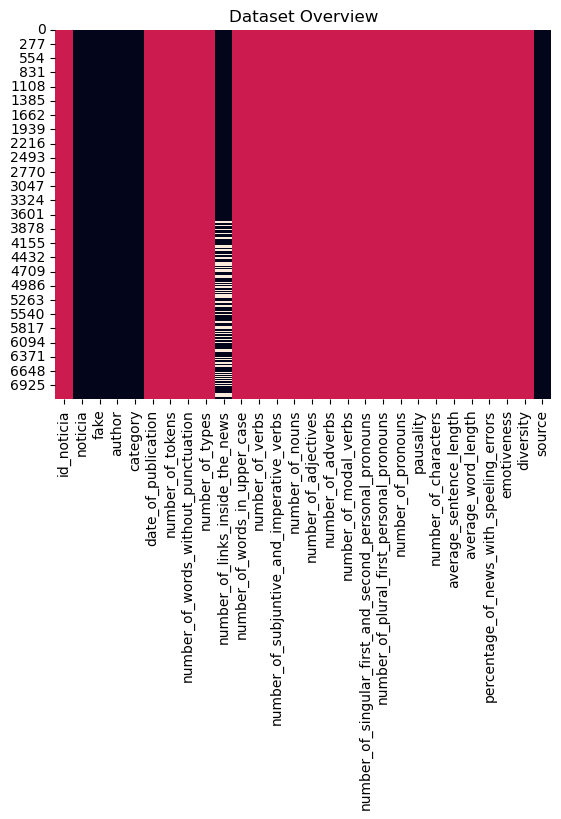

 Categerocial   Numeric   NaN 


In [28]:
dic_cols = {col:utils_recognize_type(base, col, max_cat=20) for col in base.columns}
heatmap = base.isnull()
for k,v in dic_cols.items():
    if v == "num":
        heatmap[k] = heatmap[k].apply(lambda x: 0.5 if x is False else 1)
    else:
        heatmap[k] = heatmap[k].apply(lambda x: 0 if x is False else 1)
sns.heatmap(heatmap, cbar=False).set_title('Dataset Overview')
plt.show()
print("\033[1;37;40m Categerocial ", "\033[1;30;41m Numeric ", "\033[1;30;47m NaN ")

In [29]:
base['number_of_links_inside_the_news'] = base['number_of_links_inside_the_news'].fillna(0)

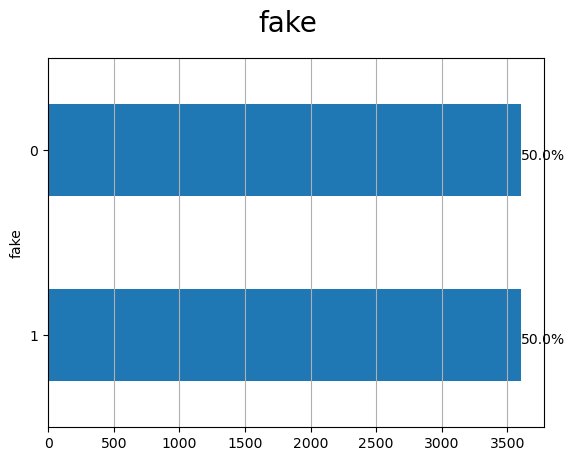

In [30]:
y = "fake"
ax = base[y].value_counts().sort_values().plot(kind="barh")
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
ax.grid(axis="x")
plt.suptitle(y, fontsize=20)
plt.show()

C:\Users\mtras\AppData\Local\Temp\ipykernel_7856\747134748.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(base[base[cat]==i][num], hist=False, label=i, ax=ax[0])
C:\Users\mtras\AppData\Local\Temp\ipykernel_7856\747134748.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplo

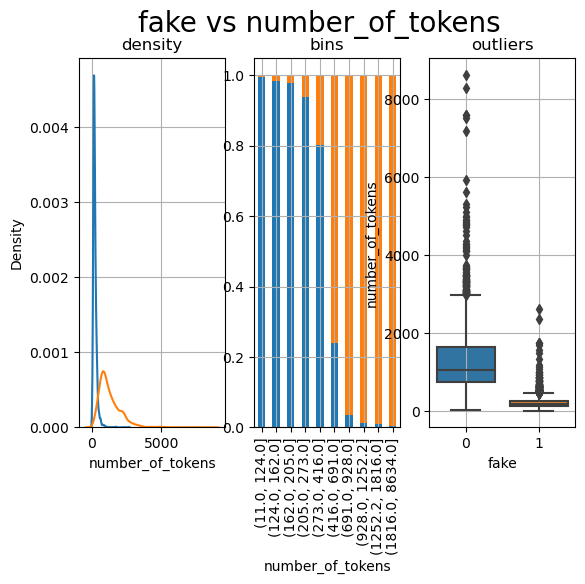

In [32]:
cat, num = "fake", "number_of_tokens"
fig, ax = plt.subplots(nrows=1, ncols=3,  sharex=False, sharey=False)

# CORREÇÃO 1: Trocando 'x' e 'y' por 'cat' e 'num' (usando f-strings para facilitar)
fig.suptitle(f"{cat} vs {num}", fontsize=20)

### distribution
ax[0].title.set_text('density')
for i in base[cat].unique():
    # Aviso: sns.distplot está obsoleto nas versões mais recentes do seaborn, 
    # se der erro no futuro, troque por sns.kdeplot(...) ou sns.histplot(..., kde=True)
    sns.distplot(base[base[cat]==i][num], hist=False, label=i, ax=ax[0])
ax[0].grid(True)

### stacked
ax[1].title.set_text('bins')
breaks = np.quantile(base[num], q=np.linspace(0,1,11))
tmp = base.groupby([cat, pd.cut(base[num], breaks, duplicates='drop')]).size().unstack().T
tmp = tmp[base[cat].unique()]
tmp["tot"] = tmp.sum(axis=1)
for col in tmp.drop("tot", axis=1).columns:
    tmp[col] = tmp[col] / tmp["tot"]
tmp.drop("tot", axis=1).plot(kind='bar', stacked=True, ax=ax[1], legend=False, grid=True)

### boxplot
ax[2].title.set_text('outliers')
# CORREÇÃO 2: Substituindo sns.catplot por sns.boxplot
sns.boxplot(x=cat, y=num, data=base, ax=ax[2]) 
ax[2].grid(True)

plt.show()

### Testes de hipótese

In [33]:
base= base.set_index(['id_noticia','noticia'])

Para as variaveis categoricas

In [34]:
from scipy.stats import chi2_contingency, fisher_exact, pointbiserialr,ttest_ind
for i in ['category','author','source']:
    # Create a contingency table
    contingency_table = pd.crosstab(base['fake'], base[i])
    
    # Perform Chi-square test of independence
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print("p-value:", p_value)
    if p_value<.05:
        print(f'A variável {i} é correlacionada com a veracidade da informação e será mantida')
    else:
        print(f'A variável {i} não é correlacionada com a veracidade da informação e será descartada')
        base= base.drop('category',axis=1)

p-value: 1.0
A variável category não é correlacionada com a veracidade da informação e será descartada
p-value: 0.0
A variável author é correlacionada com a veracidade da informação e será mantida
p-value: 0.0
A variável source é correlacionada com a veracidade da informação e será mantida


Para as contínuas

In [35]:
for i in base.columns[1:]:
    if i!='category' and i.startswith('source')==False:
        # Separate the continuous variable by the fake groups
        group_0 = base[base['fake'] == 0][i]
        group_1 = base[base['fake'] == 1][i]
        
        # Perform Point-Biserial correlation
        correlation_coefficient, p_value_point_biserial = pointbiserialr(base['fake'], base[i])
        print("p-value Point BIserial Test:", p_value_point_biserial)
        
        # Perform independent samples t-test
        t_statistic, p_value_ttest = ttest_ind(group_0, group_1)
        
        print("p-value Ttest:", p_value_ttest)
        
        if p_value_ttest<.05 and p_value_point_biserial<.05:
            print(f'A variável {i} é correlacionada com a veracidade da informação e será mantida')
        else:
            print(f'A variável {i} não é correlacionada com a veracidade da informação e será descartada')
            base= base.drop(i,axis=1)

p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável author é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.9999993945052419
p-value Ttest: 0.9999993945037162
A variável date_of_publication não é correlacionada com a veracidade da informação e será descartada
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_tokens é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_words_without_punctuation é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_types é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 1.7578219674726733e-166
p-value Ttest: 1.7578219674691774e-166
A variável number_of_links_inside_the_news é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 3.47926784

C:\Users\mtras\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Text(0.5, 1.0, 'pearson correlation')

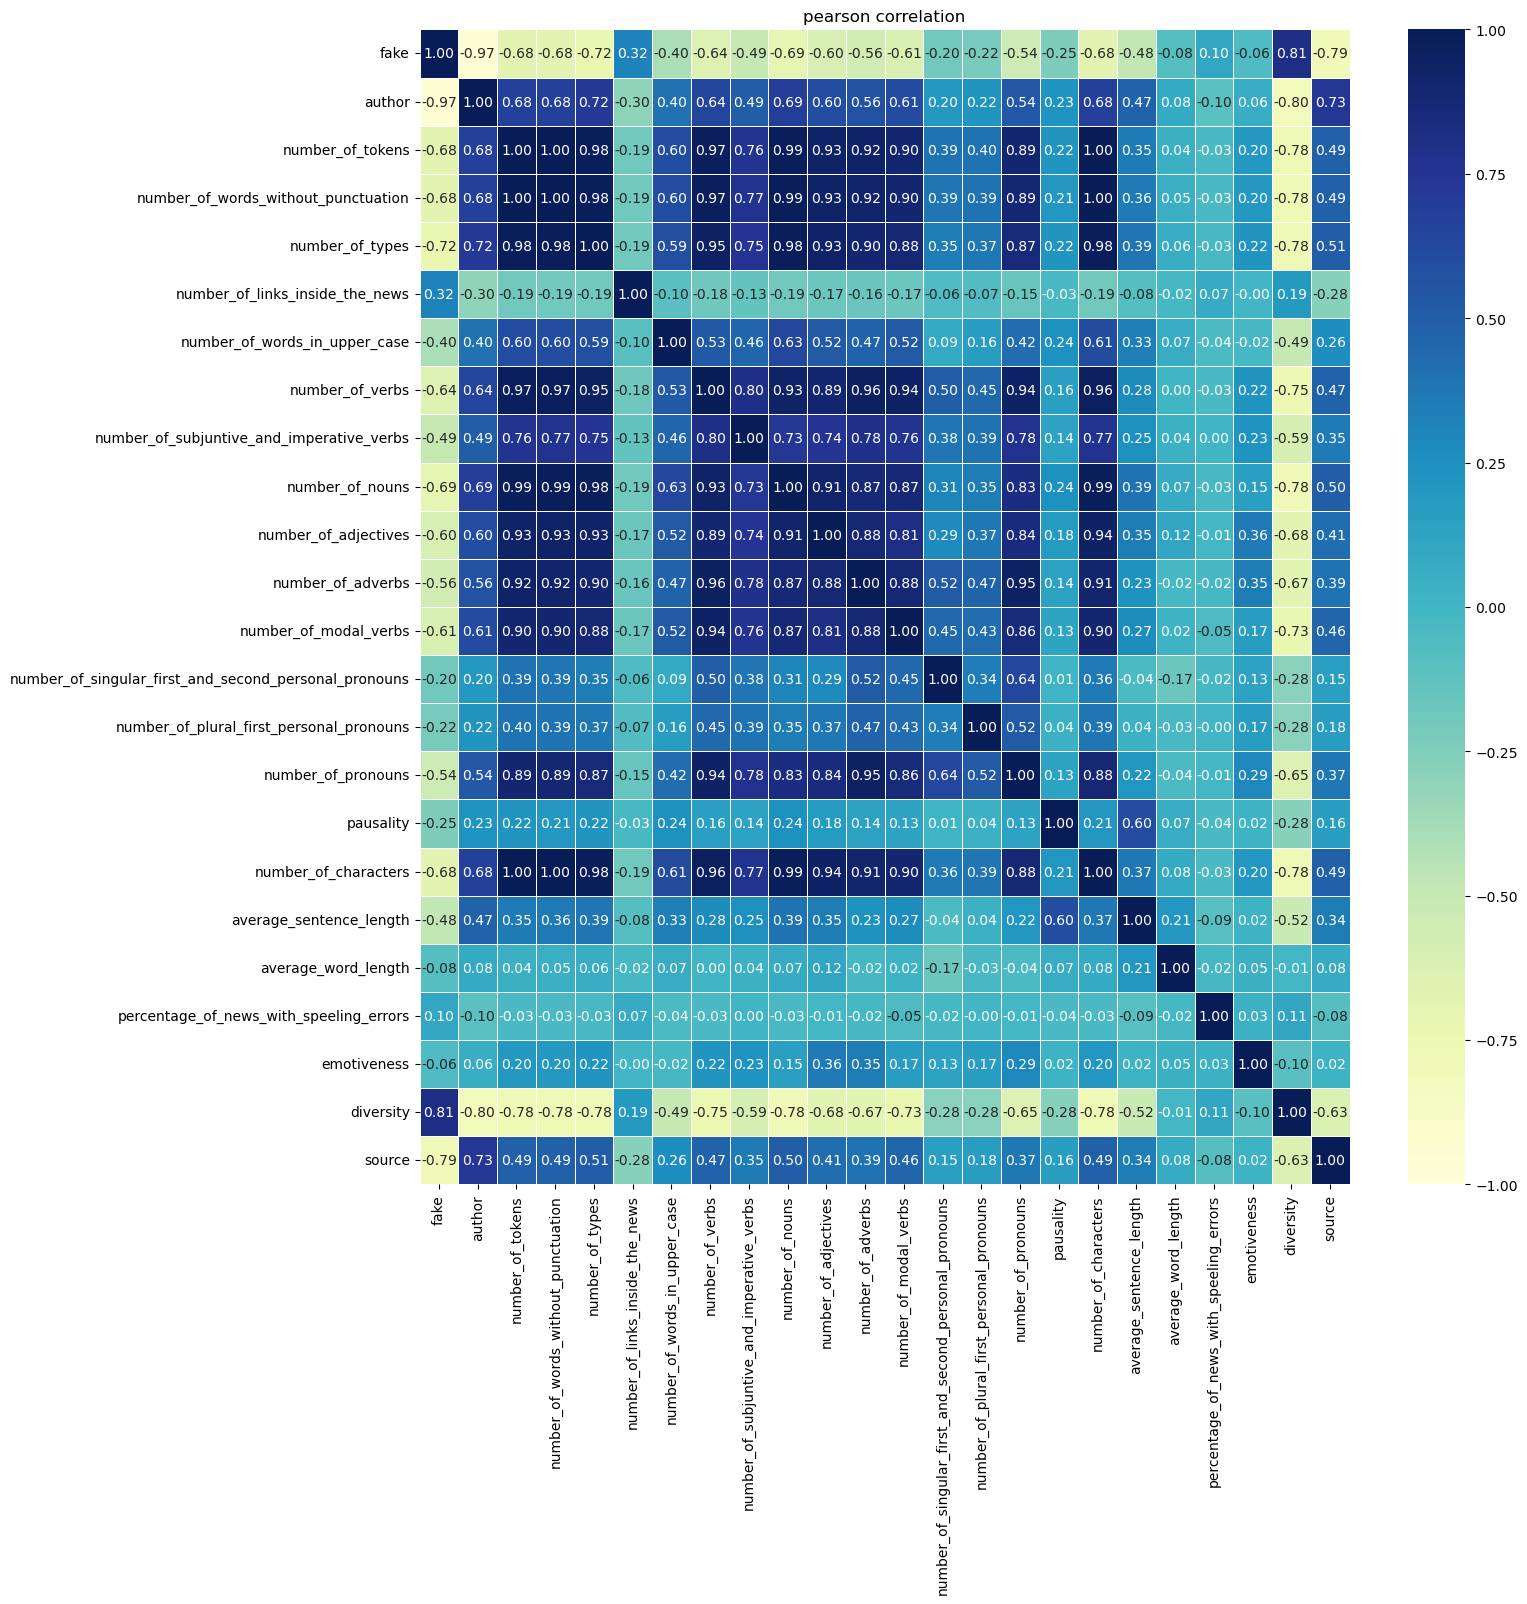

In [36]:
plt.figure(figsize=(15,15))
corr_matrix = base.copy()
for col in corr_matrix.columns:
    if corr_matrix[col].dtype == "O":
         corr_matrix[col] = corr_matrix[col].factorize(sort=True)[0]
corr_matrix = corr_matrix.corr(method="pearson")
sns.heatmap(corr_matrix, vmin=-1., vmax=1., annot=True, fmt='.2f', cmap="YlGnBu", cbar=True, linewidths=0.5)

plt.title("pearson correlation")

As features que restaram mesmo sendo redundantes demonstraram bastante importancia SHAP. Então quem vai ser excluido é:

In [37]:
## Convert categorical variable to dummy variables
dummies = pd.get_dummies(base['source'], prefix='source', drop_first=True)

# Concatenate dummy variables with original dataframe
base = pd.concat([base, dummies], axis=1)

del base['source']

## Separação do conjunto de teste e de treinamento

In [38]:
## split data
df_train, df_test = model_selection.train_test_split(base, 
                      test_size=0.3,random_state=roll_dice)
## print info
print("X_train shape:", df_train.drop("fake",axis=1).shape, "| X_test shape:", df_test.drop("fake",axis=1).shape)
print("y_train mean:", round(np.mean(df_train["fake"]),2), "| y_test mean:", round(np.mean(df_test["fake"]),2))
print(df_train.shape[1], "features:", df_train.drop("fake",axis=1).columns.to_list())

X_train shape: (5040, 30) | X_test shape: (2160, 30)
y_train mean: 0.5 | y_test mean: 0.5
31 features: ['author', 'number_of_tokens', 'number_of_words_without_punctuation', 'number_of_types', 'number_of_links_inside_the_news', 'number_of_words_in_upper_case', 'number_of_verbs', 'number_of_subjuntive_and_imperative_verbs', 'number_of_nouns', 'number_of_adjectives', 'number_of_adverbs', 'number_of_modal_verbs', 'number_of_singular_first_and_second_personal_pronouns', 'number_of_plural_first_personal_pronouns', 'number_of_pronouns', 'pausality', 'number_of_characters', 'average_sentence_length', 'average_word_length', 'percentage_of_news_with_speeling_errors', 'emotiveness', 'diversity', 'source_ceticismopolitico.com', 'source_diariodobrasil.org', 'source_estadao.com.br', 'source_folha.com.br', 'source_g1.globo.com', 'source_territorioeldorado.limao.com.br', 'source_thejornalbrasil.com.br', 'source_topfivetv.com']


### Escala a base de dados

In [39]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
X = scaler.fit_transform(df_train.drop('fake',axis=1))
df_train_scaled= pd.DataFrame(X, columns=df_train.drop('fake',axis=1).columns, index=df_train.index)
df_train_scaled["fake"] = df_train["fake"]
df_train_scaled["fake"] = df_train_scaled["fake"].astype('int')

In [40]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
X = scaler.fit_transform(df_test.drop('fake',axis=1))
df_test_scaled= pd.DataFrame(X, columns=df_test.drop('fake',axis=1).columns, index=df_test.index)
df_test_scaled["fake"] = df_test["fake"]
df_test_scaled["fake"] = df_test_scaled["fake"].astype('int')

In [41]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
# Import other classifiers you want to test

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Create a dictionary to store the classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=roll_dice),
    'Decision Tree': DecisionTreeClassifier(random_state=roll_dice),
    'Random Forest': RandomForestClassifier(random_state=roll_dice),
    'Gradient Boosting': GradientBoostingClassifier(random_state=roll_dice),
    'AdaBoost': AdaBoostClassifier(random_state=roll_dice),
    'Support Vector Machine': SVC(probability=True,random_state=roll_dice),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Neural Network': MLPClassifier(random_state=roll_dice, max_iter=600),
    'Naive Bayes': GaussianNB()
}

In [42]:
X_train = df_train_scaled[[col for col in df_train_scaled.columns if col!='fake']].fillna(0).values
y_train = df_train['fake'].values.astype('int')
X_test = df_test_scaled[[col for col in df_test_scaled.columns if col!='fake']].fillna(0).values
y_test = df_test['fake'].values.astype('int')

In [43]:
def get_cross_validation_results(Xtrain, ytrain):
    results = {}
    kfold = KFold(n_splits=5, shuffle=True, random_state=roll_dice)  # 5-fold cross-validation
    
    for name, clf in classifiers.items():
        scores = cross_val_score(clf, Xtrain, ytrain, cv=kfold, scoring='accuracy')
        results[name] = scores.mean()
    return results

In [44]:
def get_best_model(Xtrain,ytrain):
    results = get_cross_validation_results(Xtrain, ytrain)
    results = pd.DataFrame(results.items(),columns=['model','accuracy']).set_index('model')
    best_model_name=results.index[results['accuracy'].argmax()]
    best_model = classifiers[best_model_name]
    best_model.fit(Xtrain, ytrain)
    return results, best_model_name,best_model

### Observação: Só dá certo se o modelo não for o NB

In [45]:
def get_feature_importances(df_train):
    X_train= df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values
    y_train = df_train['fake'].values.astype('int')
    results,best_model_name,best_model = get_best_model(X_train,y_train)
    best_model.fit(X_train,y_train)
    if best_model_name!='Support Vector Machine':
        if best_model_name=="Logistic Regression":
            importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.coef_[0]), columns=['variavel','importancia'])
        elif  best_model_name== "Neural Network":
            importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.coefs_[0]), columns=['variavel','importancia'])
        
        else:
             importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.feature_importances_), columns=['variavel','importancia'])
                
        importancias['importancia_abs']= importancias['importancia'].apply(lambda i:np.abs(i)).all().sort_values(ascending=False)
        importancias ['expressividade absoluta']=importancias['importancia_abs']/importancias['importancia_abs'].sum()
        importancias ['expressividade para a classe']=importancias['importancia'].apply(calculate_share(importancias,'importancia'))
        importancias['classe'] = importancias['importancia'].apply(lambda i:True if i<0 else False)   
    
    else:
        importancias = "Não existe um método direto de importancia de features para Maquinas de Vetor de Suporte. Tente usar a análise SHAP"

    
    return best_model_name, best_model,importancias

In [46]:
def calculate_share(df, column_name):
    column = df[column_name]
    positive_sum = column[column > 0].sum()
    negative_sum = column[column < 0].sum()

    def calculate_share_helper(value):
        if value > 0:
            return value / positive_sum if positive_sum != 0 else 0
        elif value < 0:
            return value / negative_sum if negative_sum != 0 else 0
        else:
            return 0

    return calculate_share_helper

In [47]:
def get_test_results(model_name,model,X_train,X_test, y_train,y_test,iteration_name="All variables"): 
    #X_train= df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values
    #y_train = df_train['fake'].values.astype('int')
    #X_test= df_test[[col for col in df_test.columns if col!='fake']].fillna(0).values
    #y_test = df_test['fake'].values.astype('int')
    ## train
    model.fit(X_train, y_train)
    ## test
    y_pred = model.predict(X_test)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
    
    # Assuming you have the best model stored as 'best_model' and the test dataset as 'Xtest' and 'ytest'
    
    
    print(f"Modelo: {model_name}")
    print(f"Modelo: {model}")
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)
    print(f"F1 Score: {f1}")
    
    # Calculate recall
    recall = recall_score(y_test, y_pred)
    print(f"Recall: {recall}")
    
    # Calculate precision
    precision = precision_score(y_test, y_pred)
    print(f"Precision: {precision}")
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {iteration_name}")
    plt.savefig(f'figures/Confusion Matrix - {iteration_name}.pdf')
    plt.show()
    

## Ablação

In [48]:
df_train_scaled_context = df_train_scaled[[col for col in df_train_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication' or col=='fake']]
df_train_scaled_content = df_train_scaled[[col for col in df_train_scaled.columns if col not in df_train_scaled_context.columns or col=='fake']]
df_test_scaled_context = df_test_scaled[[col for col in df_test_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication'or col=='fake']]
df_test_scaled_content = df_test_scaled[[col for col in df_test_scaled.columns if col not in df_test_scaled_context.columns or col=='fake']]

In [49]:
df_train_context = df_train_scaled[[col for col in df_train_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication' or col=='fake']]
df_train_content = df_train_scaled[[col for col in df_train_scaled.columns if col not in df_train_context.columns or col=='fake']]
df_test_context = df_test_scaled[[col for col in df_test_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication'or col=='fake']]
df_test_content = df_test_scaled[[col for col in df_test_scaled.columns if col not in df_test_context.columns or col=='fake']]

In [50]:
X = np.vstack((df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values, df_test[[col for col in df_test.columns if col!='fake']].fillna(0).values ))
y = list(df_train_scaled_content['fake'].values.astype('int'))+list(df_test_scaled_content['fake'].values.astype('int'))

## Conteúdo

In [51]:
exclusao_redundantes= [
                        #'number_of_characters',
                        #'number_of_tokens',
                       #'number_of_subjuntive_and_imperative_verbs',  
                       #'number_of_modal_verbs',
                       'number_of_verbs',
                       "number_of_types",
                       "number_of_adjectives",
                       #"number_of_pronouns",
                       "number_of_adverbs",
                        "number_of_nouns",
                        #'number_of_words_without_punctuation' 
                        
]

In [52]:
X_train_content=df_train_scaled_content.reset_index()[[col for col in df_train_scaled_content.columns if col!='fake' and col not in exclusao_redundantes ]].fillna(0)
y_train_content=df_train_scaled_content.reset_index()['fake'].fillna(0).astype('int')
X_test_content=df_test_scaled_content.reset_index()[[col for col in df_test_scaled_content.columns if col!='fake' and col not in exclusao_redundantes]].fillna(0)
y_test_content=df_test_scaled_content.reset_index()['fake'].fillna(0).astype('int')
X_content = pd.concat([X_train_content,X_test_content],axis=0)
y_content = pd.concat([y_train_content,y_test_content],axis=0)

In [53]:
content_model_results,content_model_name,content_model= get_best_model(X_train_content,y_train_content)

C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:842: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 136, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 353, in _score
    y_pred = method_caller(estimator, "predict", X)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\utils\_response.py", line 85, in _get_response_values
    y_pred = prediction_method(X)
             ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mtras\anaconda3\Lib\

Modelo: Neural Network
Modelo: MLPClassifier(max_iter=600, random_state=0)
Accuracy: 0.9643518518518519
F1 Score: 0.9645651173492867
Recall: 0.9658986175115207
Precision: 0.9632352941176471


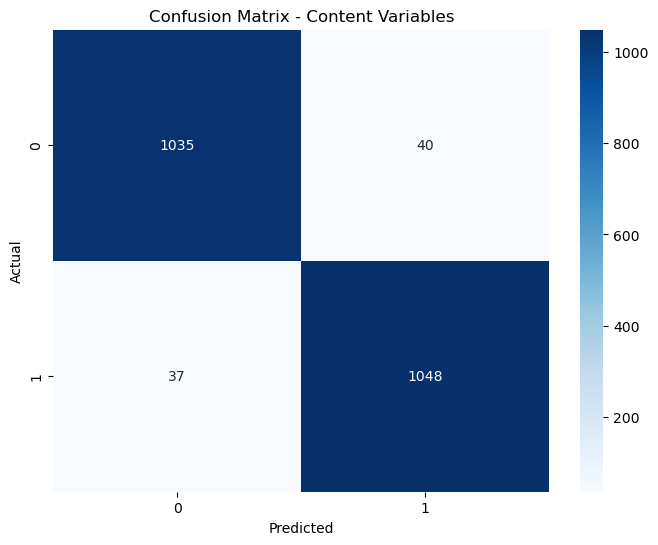

In [54]:
get_test_results(content_model_name,content_model,X_train_content,X_test_content,y_train_content,y_test_content,"Content Variables")

In [55]:
if content_model_name!='Logistic Regression' and content_model_name!="Support Vector Machine" and content_model_name!="Neural Network":
    try:
        explainer_content = shap.TreeExplainer(content_model)
    except:
        explainer_content = shap.KernelExplainer(content_model,X_train_content)
        
elif content_model_name =='Support Vector Machine' or  content_model_name=="Neural Network":
    
    def predict_wrapper(X):
        return content_model.predict_proba(X)[:, 1]  # Use the positive class probabilities

    # Create the SHAP explainer
    explainer_content = shap.Explainer(predict_wrapper, X_train_content)
    #explainer_content = shap.KernelExplainer(content_model.predict_proba(X_content)[:,1],X_content)
    
else:
    explainer_content = shap.LinearExplainer(content_model,X_train_content)

shap_values_content = explainer_content.__call__(X_content)   

PermutationExplainer explainer: 7201it [05:13, 22.52it/s]                                                              


### Explicação de todas as noticias junto

In [56]:
#shap.force_plot(0.5, shap_values_content.values,X_content.columns)

### Explicação individual

In [57]:
pd.set_option('display.max_colwidth', None)

In [58]:
df_train_content.reset_index().query("id_noticia==5753")['noticia'].to_latex()

'\\begin{tabular}{ll}\n\\toprule\n & noticia \\\\\n\\midrule\n1717 & Número de mortos após tremor na fronteira entre Iraque e Irã passa de 400. Terremoto de 7,3 de magnitude atingiu a região no domingo (12). Número de feridos passa de 6,7 mil..  O número de mortos após o tremor na região da fronteira entre Irã e Iraque passa de 400 nesta segunda-feira (13). Os feridos são mais de 6,7 mil. O epicentro do terremoto de magnitude 7,3 foi registrado a 22,4 km de Derbendîxan, no Iraque, na tarde deste domingo (12). Os trabalhos de resgate e de retirada de escombros continuam nesta manhã, e o número de vítimas pode aumentar. No Irã, 407 pessoas morreram e 6.700 ficaram feridas, de acordo com a agência de notícias Associated Press. VEJA FOTOS Já no Iraque, o tremor deixou sete mortos e 300 feridos na região do Curdistão iraquiano, segundo a CNN, citando o ministro da Saúde da região, Rekawt Hama Rasheed. A província de Suleimaniya foi a mais atingida. Esse já é o tremor que mais deixou mortos 

In [59]:
y_content.iloc[1717]

0

In [60]:
shap.plots.force(base_value=shap_values_content.base_values[1717],shap_values=shap_values_content.values[1717],features=np.round(shap_values_content.data[1717],2),feature_names=X_content.columns, matplotlib=True,show=False)
plt.savefig("figures/force_plot_content_variables_5753.pdf")

In [61]:
df_test_content.reset_index().query("id_noticia==4946")['noticia']

865    Alckmin: Adversário pode ser Lula ou outro; quem decide é a Justiça e o PT. Pré-candidato à Presidência pelo PSDB diz que ninguém está acima da lei.  Após o Supremo Tribunal Federal (STF) dar uma liminar evitando que o ex-presidente Luiz Inácio Lula da Silva seja preso até o dia 4 de abril , o governador de São Paulo e pré-candidato à Presidência, Geraldo Alckmin (PSDB) , mais uma vez que "ninguém está acima da lei". Ele declarou ainda que quem vai escolher o adversário do PSDB nas eleições será a Justiça e o PT. "Cabe respeitar a decisão do poder judiciário, não é uma decisão definitiva, cabe aguardar", disse Alckmin, após participar do lançamento da Campanha do Agasalho 2018. "Ninguém está acima da lei, a lei é para todos na República e o Judiciário é um poder independente e autônomo." + Não tem de ser privilegiado, nem destratado, diz Cármen Lúcia sobre Lula Alckmin afirmou não ver pressão no Supremo para julgar o ex-presidente. Para ele, um juiz de Suprema Corte julga de aco

In [62]:
y_content.iloc[865]

0

In [63]:
shap.force_plot(base_value=shap_values_content.base_values[865],shap_values=shap_values_content.values[865],features=np.round(shap_values_content.data[865],2),feature_names=X_content.columns, matplotlib=True, show=False)
plt.savefig("figures/force_plot_content_variables_4946.pdf")

In [64]:
df_train_content.reset_index().query("id_noticia==3010")['noticia']

672    Papa Francisco: "O Natal deste ano poderá ser o último para muitos". .  "Na metade do próximo ano (2018) o mundo estará de uma forma irreconhecível" , teria dito o Papa segundo o portal inglês The Mirror. O Papa, que anteriormente havia anunciado o começo da Terceira Guerra Mundial, classificou o Natal desse ano como uma "charada", durante uma missa na celebração da Semana Eucarística . No discurso, Francisco citou os ataques terroristas que ocorreram pelo mundo durante os últimos anos e a possibilidade real de uma guerra nuclear. "Estaremos fechados para o Natal deste ano. Haverão luzes, haverão festas, árvores brilhantes, e até cenários natalinos, tudo às mil maravilhas. Enquanto isso, o mundo continuará em guerra", disse o Papa. O Pontífice elaborou para o seu discurso a seguinte fala: "Enquanto o mundo passa fome, queima e se declina para um caos maior, nós devemos perceber que a celebração natalina durante esse ano, para aqueles que irão celebrar, pode ser a última". Franci

In [65]:
y_content.iloc[672]

1

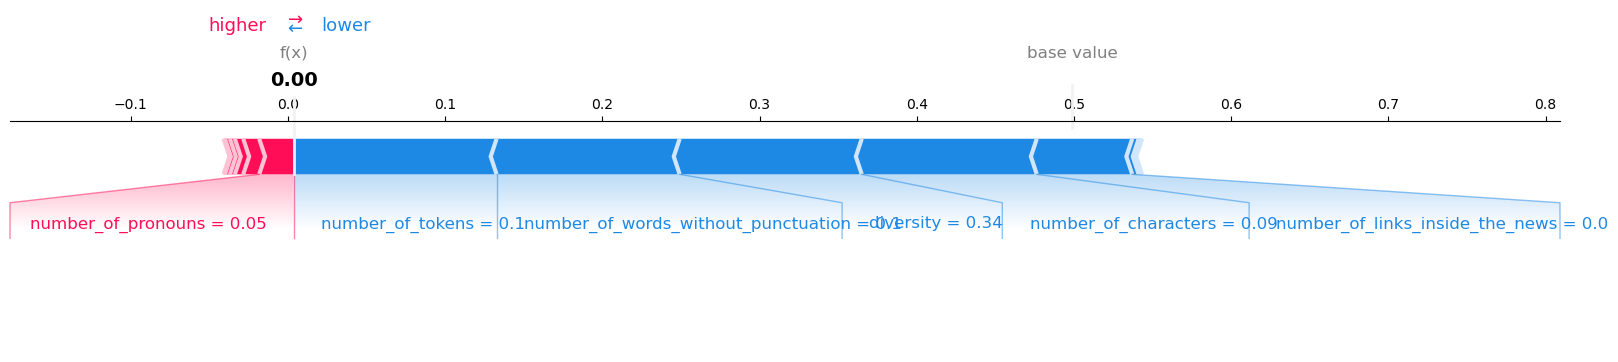

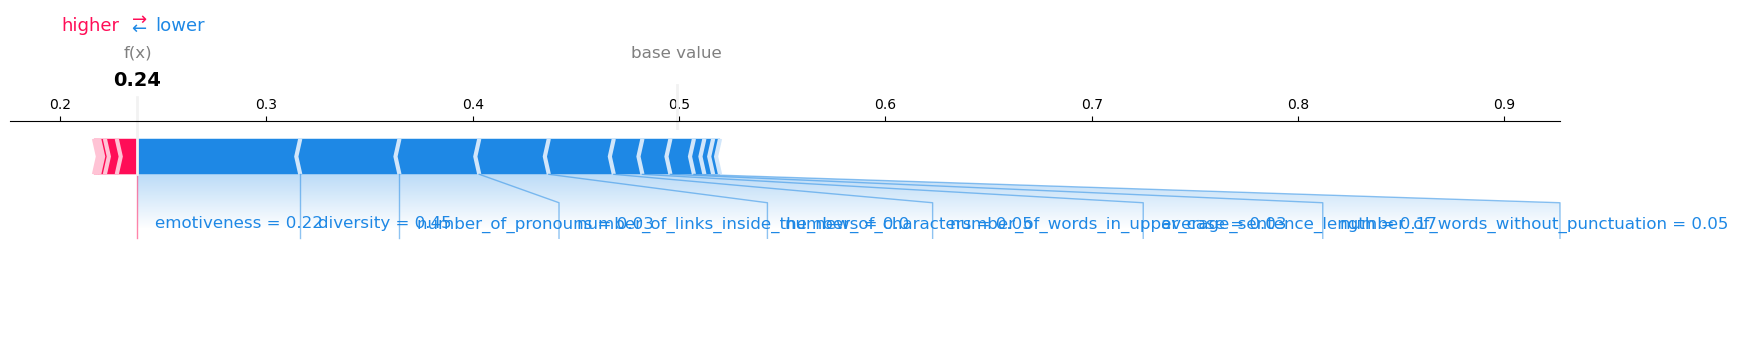

In [66]:
plt.show()

In [67]:
shap.plots.force(base_value=shap_values_content.base_values[672],shap_values=shap_values_content.values[672],features=np.round(shap_values_content.data[672],2),feature_names=X_content.columns, show=False, matplotlib=True)
plt.savefig("figures/force_plot_content_variables_3010.pdf")

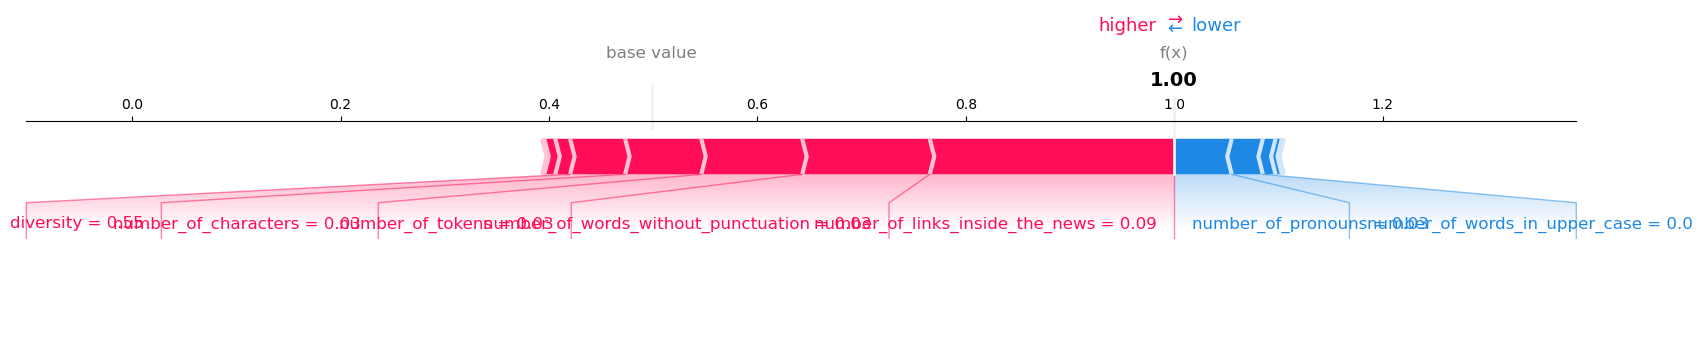

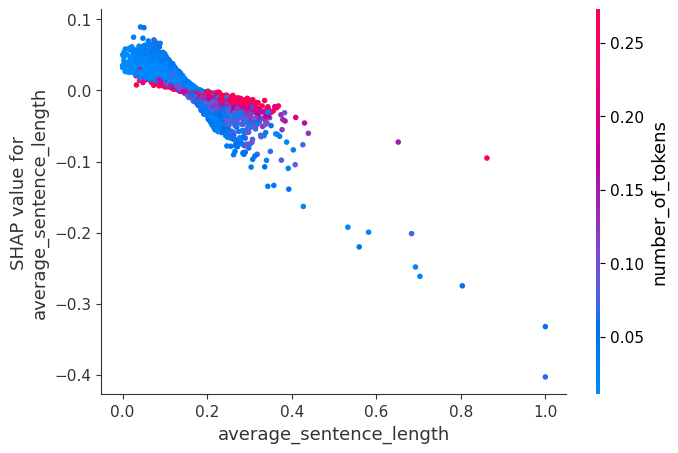

In [68]:
shap.dependence_plot('average_sentence_length', shap_values_content.values, X_content)

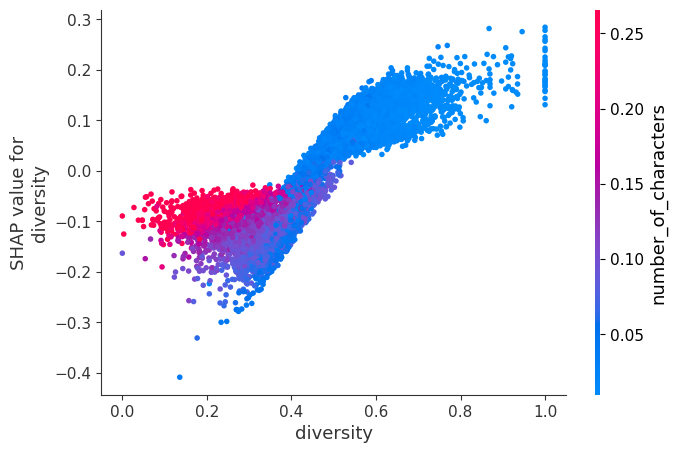

In [69]:
shap.dependence_plot('diversity', shap_values_content.values, X_content)

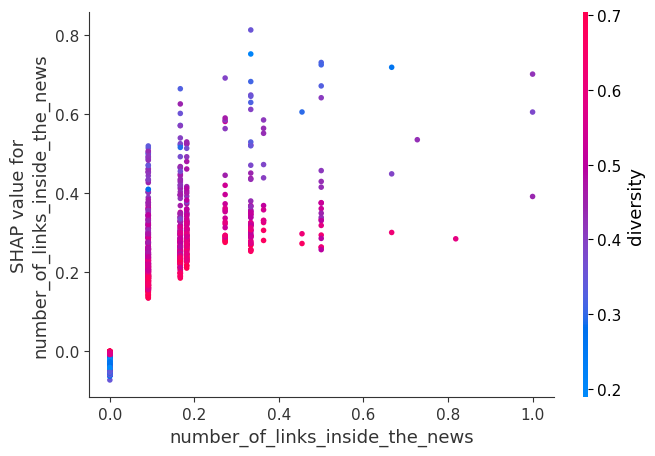

In [70]:
shap.dependence_plot('number_of_links_inside_the_news', shap_values_content.values, X_content)

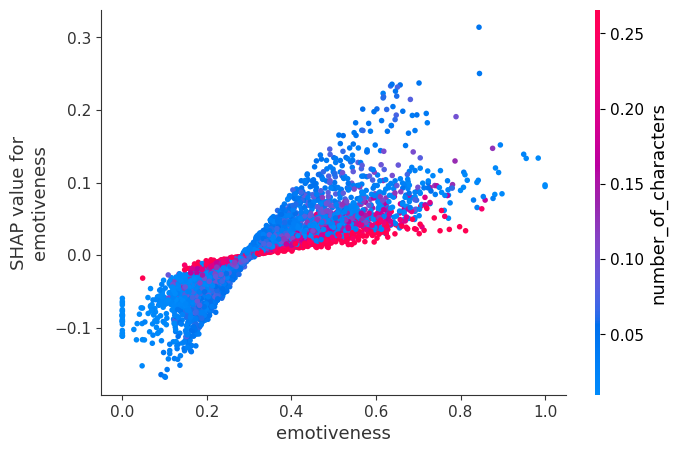

In [71]:
shap.dependence_plot('emotiveness', shap_values_content.values, X_content)

In [72]:
plt.figure(figsize=(10,5))
shap.summary_plot(shap_values_content.values, X_content, show=False)
plt.savefig("figures/summaryplot_content_variables.pdf")

## Contexto

In [73]:
X_train_context=df_train_scaled_context.reset_index()[[col for col in df_train_scaled_context.columns if col!='fake']].fillna(0)
y_train_context=df_train_scaled_context.reset_index()['fake'].fillna(0).astype('int')
X_test_context=df_test_scaled_context.reset_index()[[col for col in df_test_scaled_context.columns if col!='fake']].fillna(0)
y_test_context=df_test_scaled_context.reset_index()['fake'].fillna(0).astype('int')
X_context = pd.concat([X_train_context,X_test_context],axis=0)
y_context = pd.concat([y_train_context,y_test_context],axis=0)

In [74]:
context_model_results,context_model_name,context_model= get_best_model(X_train_context,y_train_context)

Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.9990740740740741
F1 Score: 0.9990791896869246
Recall: 1.0
Precision: 0.9981600735970562


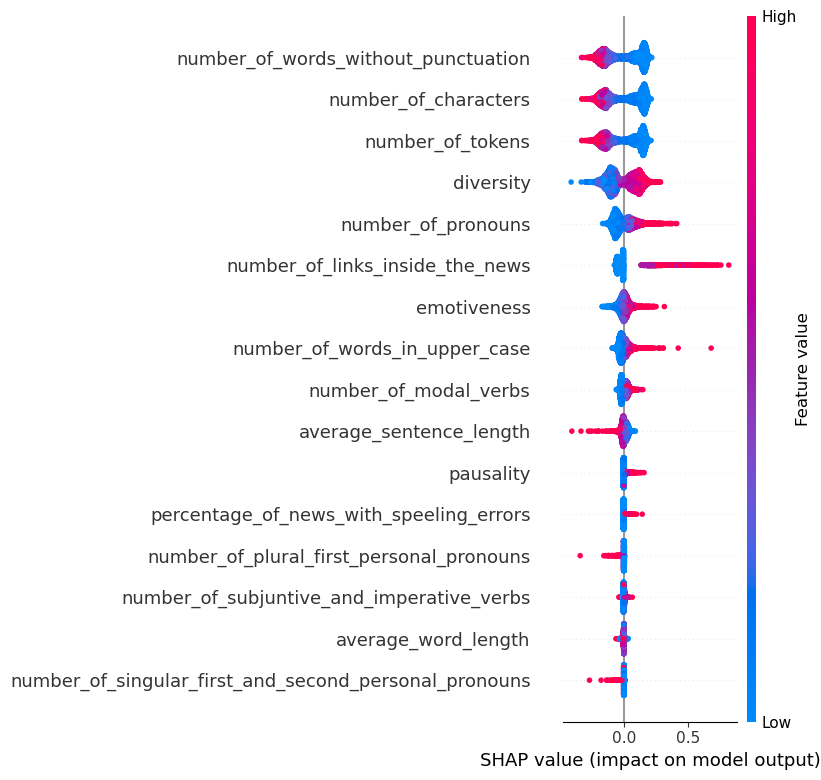

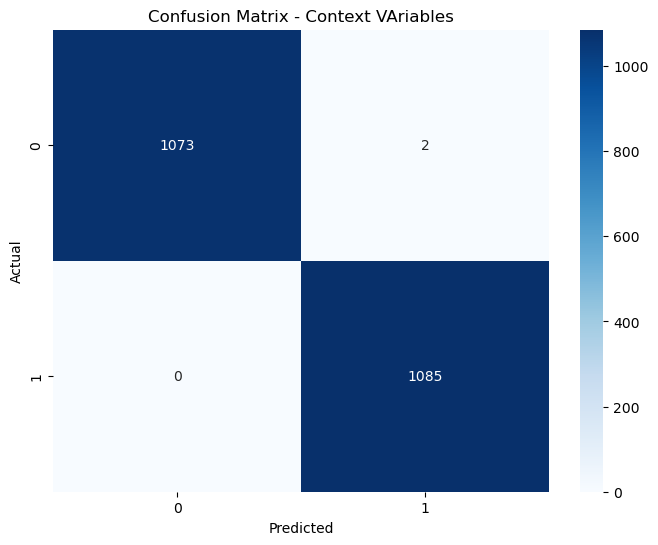

In [75]:
get_test_results(context_model_name,context_model,X_train_context,X_test_context,y_train_context,y_test_context,"Context VAriables")

In [76]:
if context_model_name!='Logistic Regression' and context_model_name!="Support Vector Machine" and context_model_name!="Neural Network":
    try:
        explainer_context = shap.TreeExplainer(context_model)
    except:
        explainer_context = shap.KernelExplainer(context_model,X_train_context)
        
elif context_model_name =='Support Vector Machine' or  context_model_name=="Neural Network":
    
    def predict_wrapper(X):
        return context_model.predict_proba(X)[:, 1]  # Use the positive class probabilities

    # Create the SHAP explainer
    explainer_context = shap.Explainer(predict_wrapper, X_train_context)
    #explainer_context = shap.KernelExplainer(context_model.predict_proba(X_context)[:,1],X_context)
    
else:
    explainer_context = shap.LinearExplainer(context_model,X_train_context)

shap_values_context = explainer_context.__call__(X_context)  

### Explicação de todas as noticias junto

In [77]:
df_train_context.reset_index().query("id_noticia==5753")['noticia']

1717    Número de mortos após tremor na fronteira entre Iraque e Irã passa de 400. Terremoto de 7,3 de magnitude atingiu a região no domingo (12). Número de feridos passa de 6,7 mil..  O número de mortos após o tremor na região da fronteira entre Irã e Iraque passa de 400 nesta segunda-feira (13). Os feridos são mais de 6,7 mil. O epicentro do terremoto de magnitude 7,3 foi registrado a 22,4 km de Derbendîxan, no Iraque, na tarde deste domingo (12). Os trabalhos de resgate e de retirada de escombros continuam nesta manhã, e o número de vítimas pode aumentar. No Irã, 407 pessoas morreram e 6.700 ficaram feridas, de acordo com a agência de notícias Associated Press. VEJA FOTOS Já no Iraque, o tremor deixou sete mortos e 300 feridos na região do Curdistão iraquiano, segundo a CNN, citando o ministro da Saúde da região, Rekawt Hama Rasheed. A província de Suleimaniya foi a mais atingida. Esse já é o tremor que mais deixou mortos em 2017, superando o número de vítimas do sismo que atingiu o

In [78]:
y_context.iloc[1717]

0

In [79]:
shap.force_plot(base_value=shap_values_context.base_values[1717],shap_values=shap_values_context.values[1717],features=np.round(shap_values_context.data[1717],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/force_plot_context_variables_5753.pdf")

In [80]:
df_test_context.reset_index().query("id_noticia==4946")['noticia']

865    Alckmin: Adversário pode ser Lula ou outro; quem decide é a Justiça e o PT. Pré-candidato à Presidência pelo PSDB diz que ninguém está acima da lei.  Após o Supremo Tribunal Federal (STF) dar uma liminar evitando que o ex-presidente Luiz Inácio Lula da Silva seja preso até o dia 4 de abril , o governador de São Paulo e pré-candidato à Presidência, Geraldo Alckmin (PSDB) , mais uma vez que "ninguém está acima da lei". Ele declarou ainda que quem vai escolher o adversário do PSDB nas eleições será a Justiça e o PT. "Cabe respeitar a decisão do poder judiciário, não é uma decisão definitiva, cabe aguardar", disse Alckmin, após participar do lançamento da Campanha do Agasalho 2018. "Ninguém está acima da lei, a lei é para todos na República e o Judiciário é um poder independente e autônomo." + Não tem de ser privilegiado, nem destratado, diz Cármen Lúcia sobre Lula Alckmin afirmou não ver pressão no Supremo para julgar o ex-presidente. Para ele, um juiz de Suprema Corte julga de aco

In [81]:
y_context.iloc[865]

0

In [82]:
shap.force_plot(base_value=shap_values_context.base_values[865],shap_values=shap_values_context.values[865],features=np.round(shap_values_context.data[865],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/force_plot_context_variables_4946.pdf")

In [83]:
df_train_context.reset_index().query("id_noticia==3010")['noticia']

672    Papa Francisco: "O Natal deste ano poderá ser o último para muitos". .  "Na metade do próximo ano (2018) o mundo estará de uma forma irreconhecível" , teria dito o Papa segundo o portal inglês The Mirror. O Papa, que anteriormente havia anunciado o começo da Terceira Guerra Mundial, classificou o Natal desse ano como uma "charada", durante uma missa na celebração da Semana Eucarística . No discurso, Francisco citou os ataques terroristas que ocorreram pelo mundo durante os últimos anos e a possibilidade real de uma guerra nuclear. "Estaremos fechados para o Natal deste ano. Haverão luzes, haverão festas, árvores brilhantes, e até cenários natalinos, tudo às mil maravilhas. Enquanto isso, o mundo continuará em guerra", disse o Papa. O Pontífice elaborou para o seu discurso a seguinte fala: "Enquanto o mundo passa fome, queima e se declina para um caos maior, nós devemos perceber que a celebração natalina durante esse ano, para aqueles que irão celebrar, pode ser a última". Franci

In [84]:
y_context.iloc[672]

1

In [85]:
shap.force_plot(base_value=shap_values_context.base_values[672],shap_values=shap_values_context.values[672],features=np.round(shap_values_context.data[672],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/force_plot_context_variables_3010.pdf")

In [86]:
#shap.force_plot(explainer_context.expected_value, shap_values_context,X_context.columns)

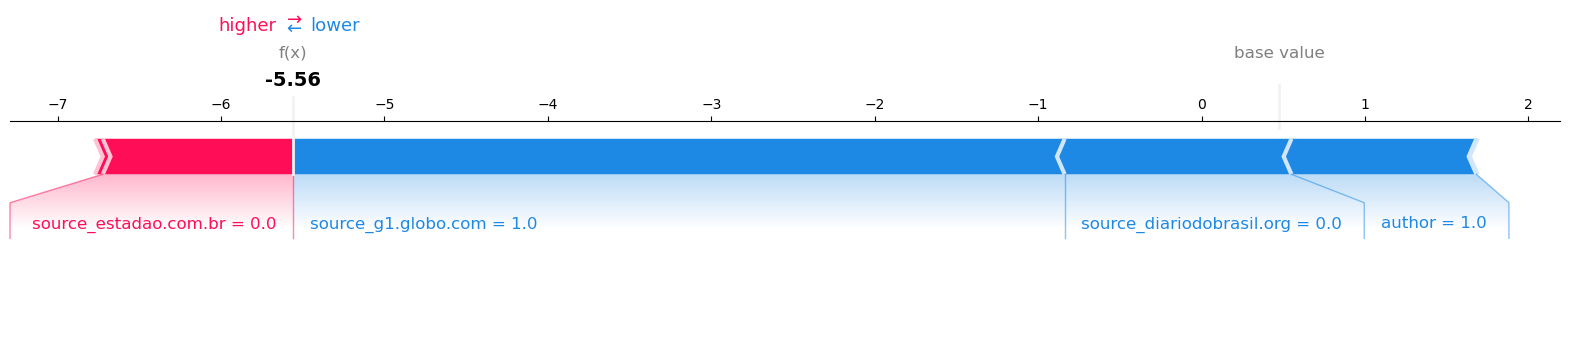

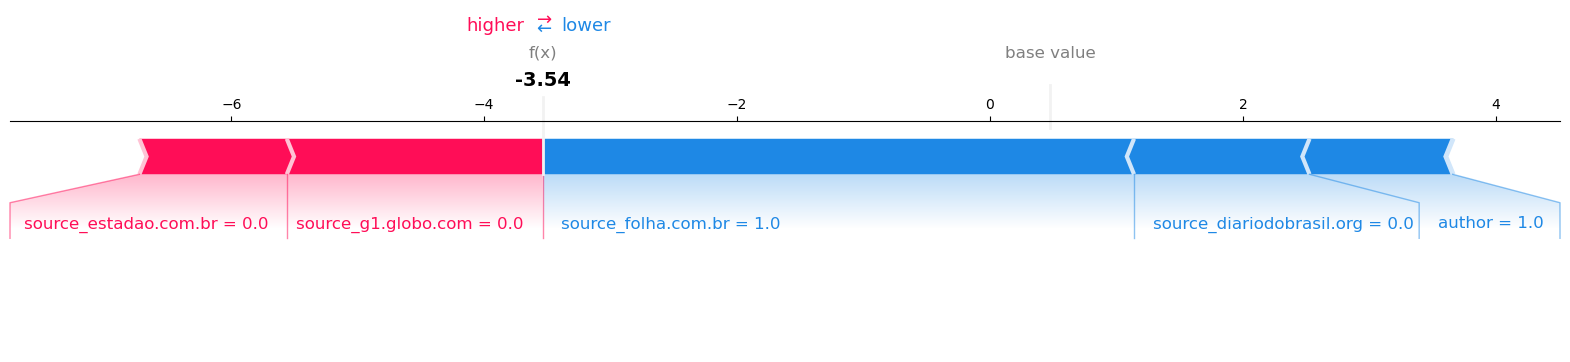

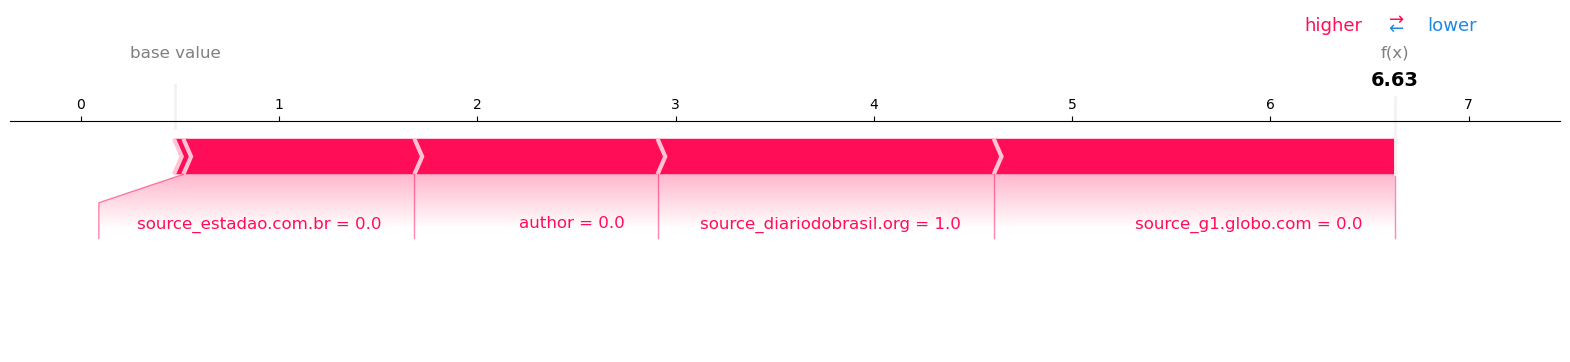

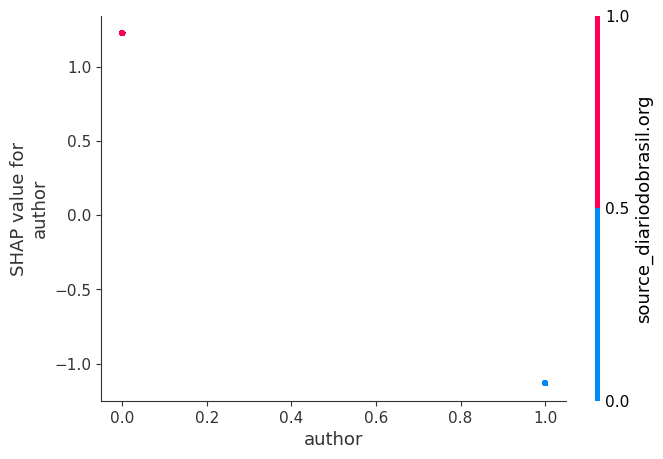

In [87]:
shap.dependence_plot('author', shap_values_context.values, X_context)

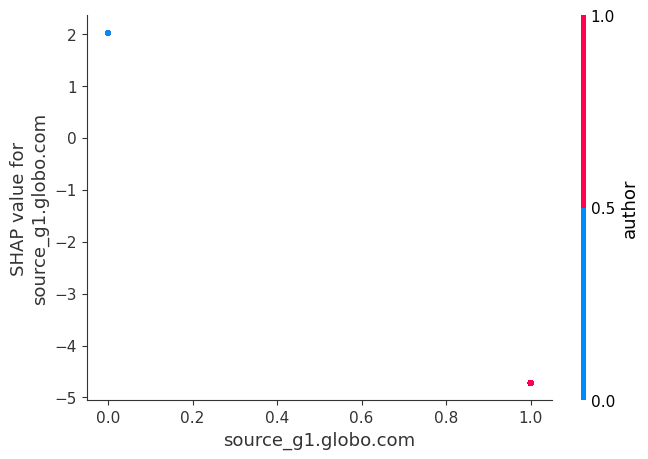

In [88]:
shap.dependence_plot('source_g1.globo.com', shap_values_context.values, X_context)

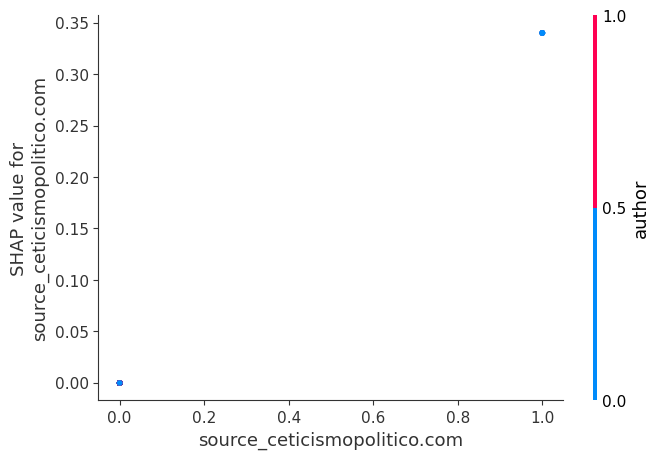

In [89]:
shap.dependence_plot('source_ceticismopolitico.com', shap_values_context.values, X_context)

In [90]:
plt.figure(figsize=(10,5))
shap.summary_plot(shap_values_context, X_context, show=False)
plt.savefig("figures/summaryplot_context_variables.pdf")

## Conteúdo + Contexto

In [91]:
shap.initjs()
X_train=df_train_scaled.reset_index()[[col for col in df_train_scaled.columns if col!='fake']].fillna(0)
y_train=df_train_scaled.reset_index()['fake'].fillna(0).astype('int')
X_test=df_test_scaled.reset_index()[[col for col in df_test_scaled.columns if col!='fake']].fillna(0)
y_test=df_test_scaled.reset_index()['fake'].fillna(0).astype('int')
X = pd.concat([X_train,X_test],axis=0)
y = pd.concat([y_train,y_test],axis=0)


In [92]:
general_model_results,general_model_name,general_model= get_best_model(X_train,y_train)

C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:842: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 136, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 353, in _score
    y_pred = method_caller(estimator, "predict", X)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mtras\anaconda3\Lib\site-packages\sklearn\utils\_response.py", line 85, in _get_response_values
    y_pred = prediction_method(X)
             ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mtras\anaconda3\Lib\

Modelo: Gradient Boosting
Modelo: GradientBoostingClassifier(random_state=0)
Accuracy: 0.9990740740740741
F1 Score: 0.9990791896869246
Recall: 1.0
Precision: 0.9981600735970562


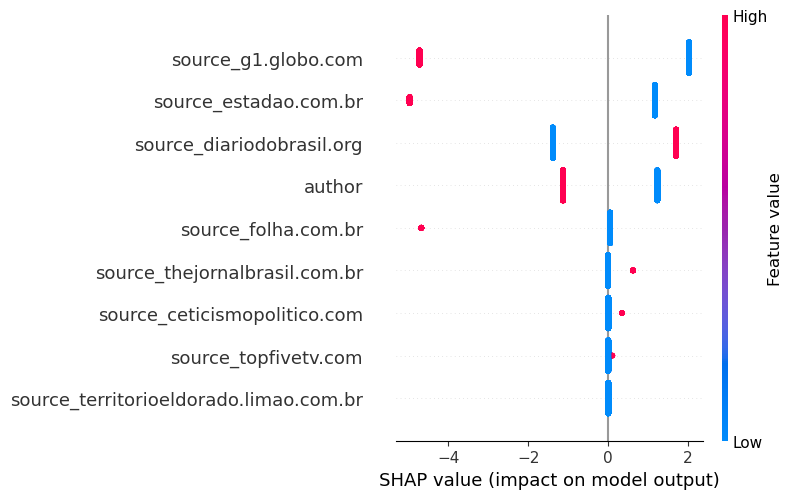

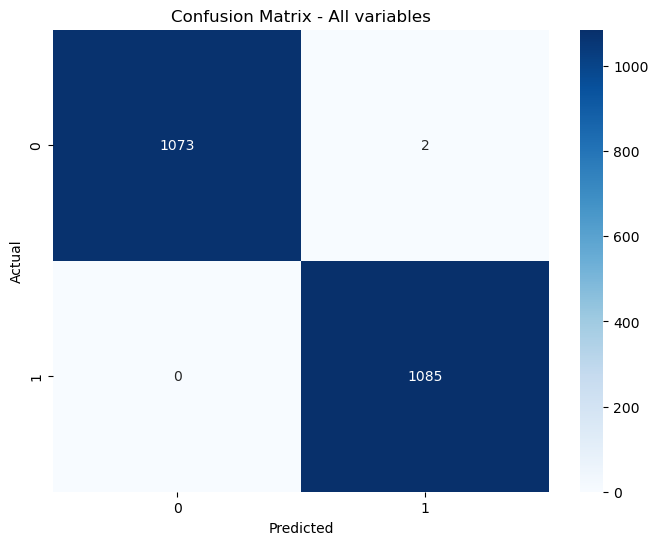

In [93]:
get_test_results(general_model_name,general_model,X_train,X_test,y_train,y_test)

In [94]:
if general_model_name!='Logistic Regression' and general_model_name!="Support Vector Machine" and general_model_name!="Neural Network":
    try:
        explainer_general = shap.TreeExplainer(general_model)
    except:
        explainer_genreral = shap.KernelExplainer(general_model,X_train)
        
elif general_model_name =='Support Vector Machine' or  general_model_name=="Neural Network":
    
    def predict_wrapper(X):
        return general_model.predict_proba(X)[:, 1]  # Use the positive class probabilities

    # Create the SHAP explainer
    explainer_general = shap.Explainer(predict_wrapper, X_train)
    #explainer_context = shap.KernelExplainer(context_model.predict_proba(X_context)[:,1],X_context)
    
else:
    explainer_general = shap.LinearExplainer(general_model,X_train)

shap_values_general = explainer_general.__call__(X)  

### Explicação de todas as noticias junto

In [95]:
#shap.force_plot(explainer.expected_value, shap_values,X.columns)

### Explicação individual

In [96]:
df_train.reset_index().query("id_noticia==5753")['noticia']

1717    Número de mortos após tremor na fronteira entre Iraque e Irã passa de 400. Terremoto de 7,3 de magnitude atingiu a região no domingo (12). Número de feridos passa de 6,7 mil..  O número de mortos após o tremor na região da fronteira entre Irã e Iraque passa de 400 nesta segunda-feira (13). Os feridos são mais de 6,7 mil. O epicentro do terremoto de magnitude 7,3 foi registrado a 22,4 km de Derbendîxan, no Iraque, na tarde deste domingo (12). Os trabalhos de resgate e de retirada de escombros continuam nesta manhã, e o número de vítimas pode aumentar. No Irã, 407 pessoas morreram e 6.700 ficaram feridas, de acordo com a agência de notícias Associated Press. VEJA FOTOS Já no Iraque, o tremor deixou sete mortos e 300 feridos na região do Curdistão iraquiano, segundo a CNN, citando o ministro da Saúde da região, Rekawt Hama Rasheed. A província de Suleimaniya foi a mais atingida. Esse já é o tremor que mais deixou mortos em 2017, superando o número de vítimas do sismo que atingiu o

In [97]:
y.iloc[1717]

0

In [98]:
shap.force_plot(base_value=shap_values_general.base_values[1717],shap_values=shap_values_general.values[1717],features=np.round(shap_values_general.data[1717],2),feature_names=X.columns, matplotlib=True,show=False)
plt.savefig("figures/force_plot_all_variables_5753.pdf")

In [99]:
df_test.reset_index().query("id_noticia==4946")['noticia']

865    Alckmin: Adversário pode ser Lula ou outro; quem decide é a Justiça e o PT. Pré-candidato à Presidência pelo PSDB diz que ninguém está acima da lei.  Após o Supremo Tribunal Federal (STF) dar uma liminar evitando que o ex-presidente Luiz Inácio Lula da Silva seja preso até o dia 4 de abril , o governador de São Paulo e pré-candidato à Presidência, Geraldo Alckmin (PSDB) , mais uma vez que "ninguém está acima da lei". Ele declarou ainda que quem vai escolher o adversário do PSDB nas eleições será a Justiça e o PT. "Cabe respeitar a decisão do poder judiciário, não é uma decisão definitiva, cabe aguardar", disse Alckmin, após participar do lançamento da Campanha do Agasalho 2018. "Ninguém está acima da lei, a lei é para todos na República e o Judiciário é um poder independente e autônomo." + Não tem de ser privilegiado, nem destratado, diz Cármen Lúcia sobre Lula Alckmin afirmou não ver pressão no Supremo para julgar o ex-presidente. Para ele, um juiz de Suprema Corte julga de aco

In [100]:
y.iloc[865]

0

In [101]:
shap.force_plot(base_value=shap_values_general.base_values[865],shap_values=shap_values_general.values[865],features=np.round(shap_values_general.data[865],2),feature_names=X.columns, matplotlib=True,show=False)
plt.savefig("figures/force_plot_all_variables_4946.pdf")

In [102]:
df_train.reset_index().query("id_noticia==3010")['noticia']

672    Papa Francisco: "O Natal deste ano poderá ser o último para muitos". .  "Na metade do próximo ano (2018) o mundo estará de uma forma irreconhecível" , teria dito o Papa segundo o portal inglês The Mirror. O Papa, que anteriormente havia anunciado o começo da Terceira Guerra Mundial, classificou o Natal desse ano como uma "charada", durante uma missa na celebração da Semana Eucarística . No discurso, Francisco citou os ataques terroristas que ocorreram pelo mundo durante os últimos anos e a possibilidade real de uma guerra nuclear. "Estaremos fechados para o Natal deste ano. Haverão luzes, haverão festas, árvores brilhantes, e até cenários natalinos, tudo às mil maravilhas. Enquanto isso, o mundo continuará em guerra", disse o Papa. O Pontífice elaborou para o seu discurso a seguinte fala: "Enquanto o mundo passa fome, queima e se declina para um caos maior, nós devemos perceber que a celebração natalina durante esse ano, para aqueles que irão celebrar, pode ser a última". Franci

In [103]:
y.iloc[672]

1

In [104]:
shap.force_plot(base_value=shap_values_general.base_values[672],shap_values=shap_values_general.values[672],features=np.round(shap_values_general.data[672],2),feature_names=X.columns, matplotlib=True,show=False)
plt.savefig("figures/force_plot_all_variables_3010.pdf")

In [105]:
#shap.force_plot(explainer_context.expected_value, shap_values_context,X_context.columns)

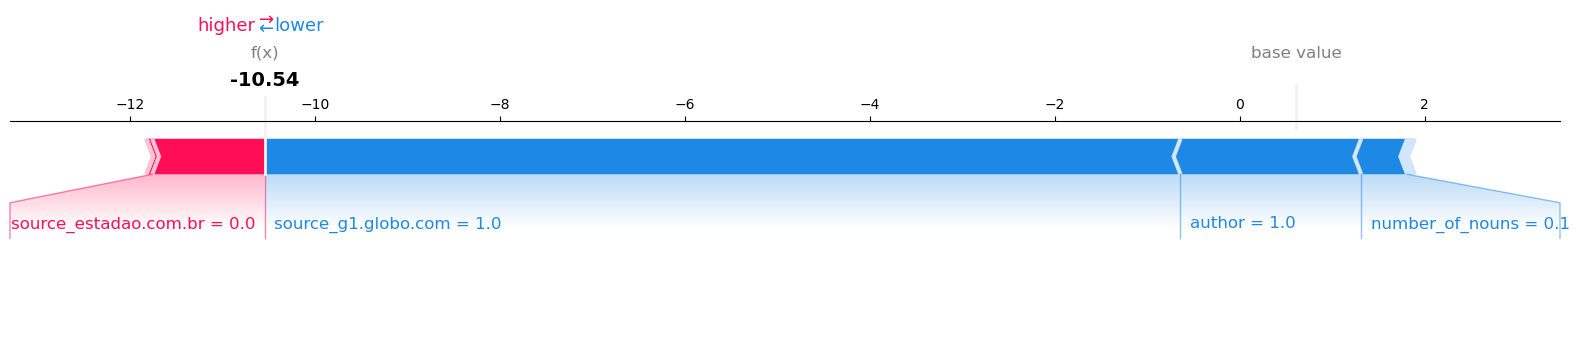

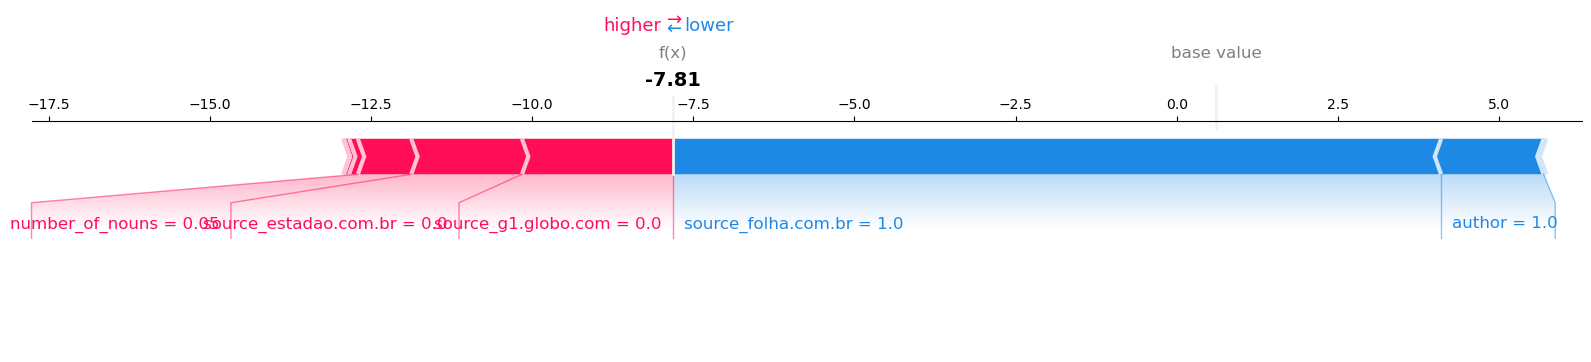

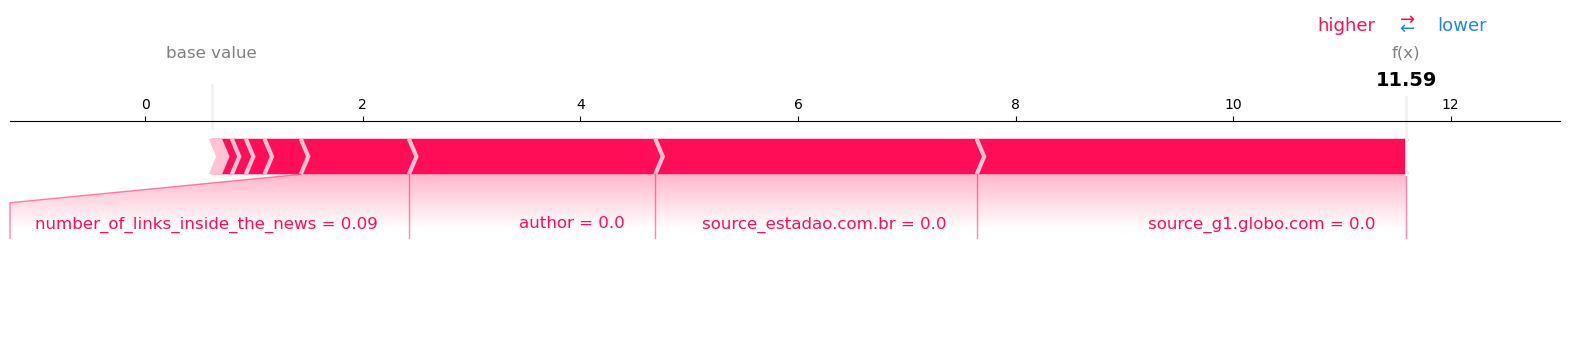

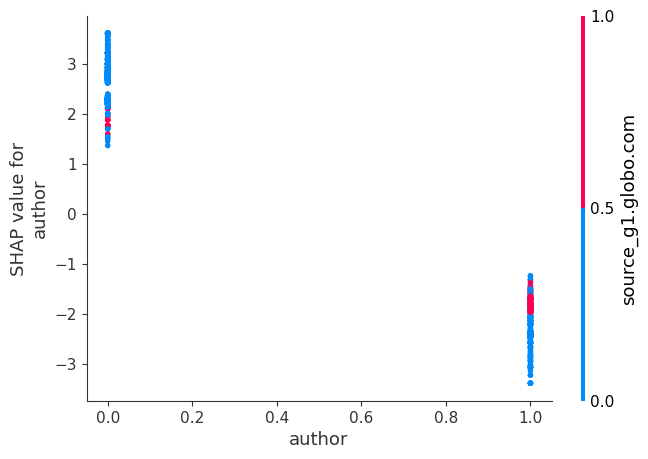

In [106]:
shap.dependence_plot('author', shap_values_general.values, X)

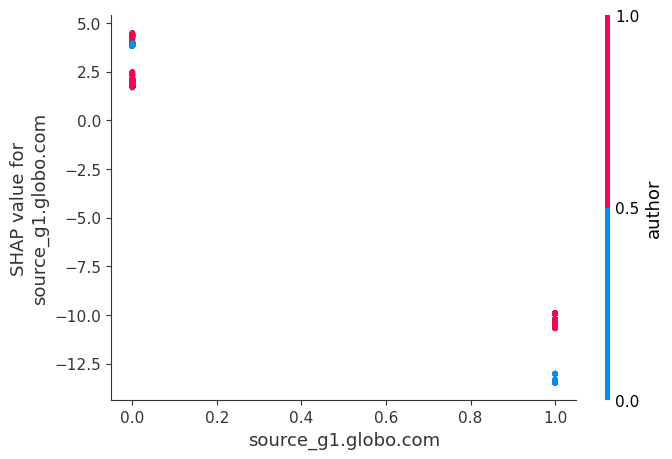

In [107]:
shap.dependence_plot('source_g1.globo.com', shap_values_general.values, X)

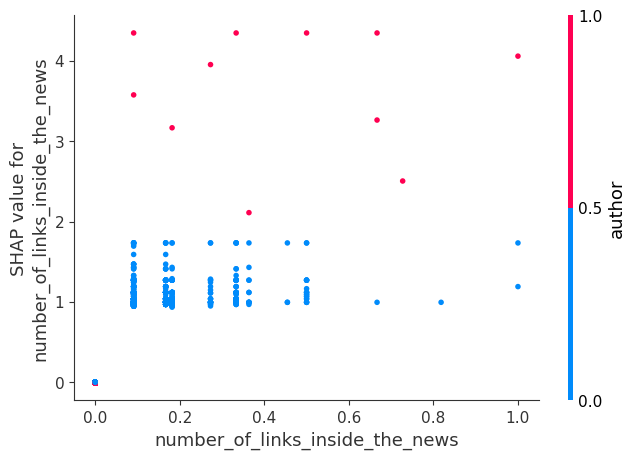

In [108]:
shap.dependence_plot('number_of_links_inside_the_news', shap_values_general.values, X)

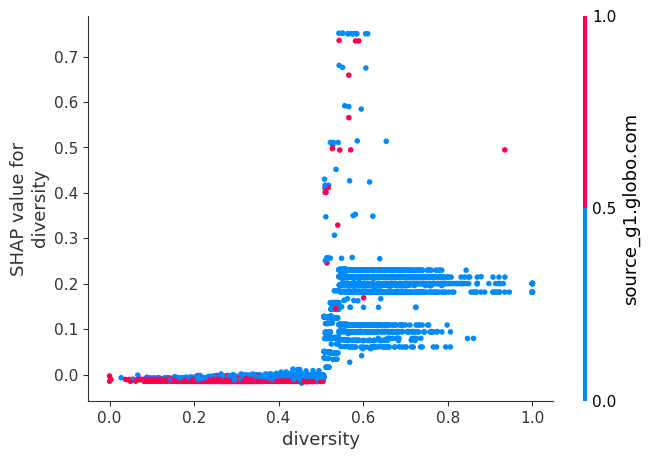

In [109]:
shap.dependence_plot('diversity', shap_values_general.values, X)

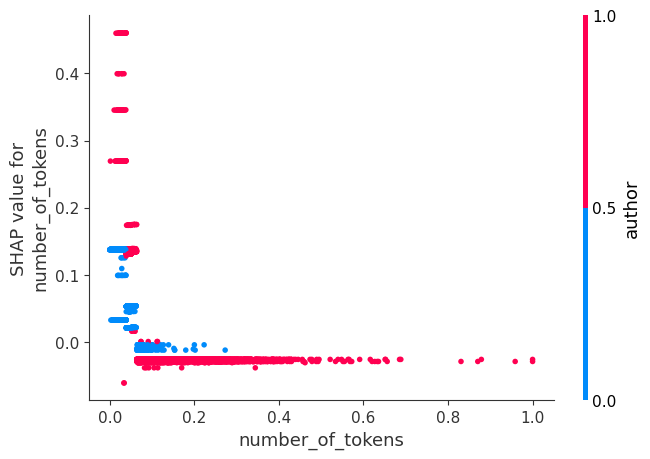

In [110]:
shap.dependence_plot('number_of_tokens', shap_values_general.values, X)

In [111]:
plt.figure(figsize=(10,5))
shap.summary_plot(shap_values_general, X, show=False)
plt.savefig("figures/summaryplot_all_variables.pdf")